>>KB1
KB = {'X2|!X1', 'X1'}
alpha = {'X2'}
PL-Resolution entailment: False
DPLL entailment: True
Algorithms agree: False
-----------------------------------
>>KB2
KB = {'!B|!A|C', 'B|!A', 'A'}
alpha = {'C', 'B|A'}
PL-Resolution entailment: False
DPLL entailment: True
Algorithms agree: False
-----------------------------------
>>KB3
KB = {'!Earthquake|Alarm', '!Alarm|MaryCall', '!Burglar|Alarm', '!Alarm|JohnCall'}
alpha = {'!Burglar|MaryCall', '!Burglar|JohnCall'}
PL-Resolution entailment: False
DPLL entailment: True
Algorithms agree: False
-----------------------------------
>>False Case
KB = {'A|B'}
alpha = {'A'}
PL-Resolution entailment: False
DPLL entailment: False
Algorithms agree: True
-----------------------------------


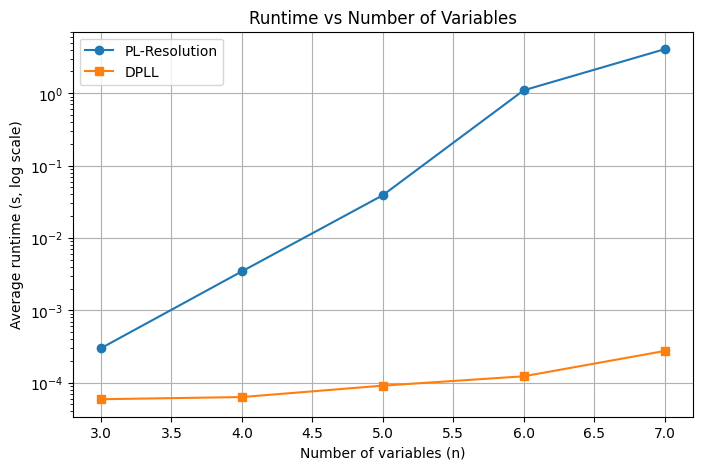

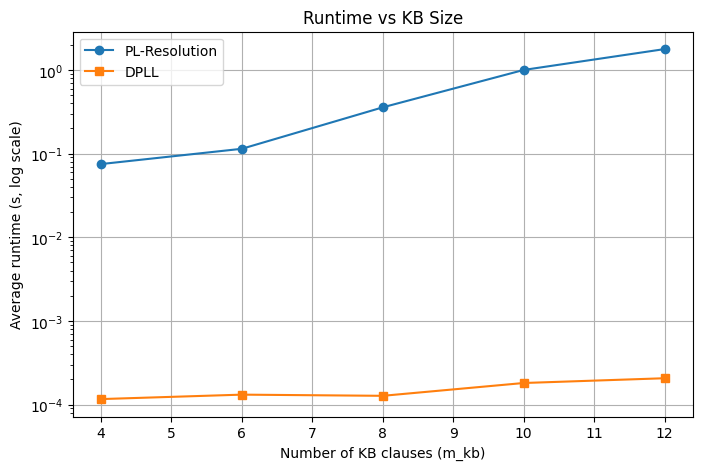

In [2]:
import numpy as np
import itertools
import time
import matplotlib.pyplot as plt

# --- Utility class for CNF operations ---
class KBUtils:
    """Helper functions for propositional logic operations."""

    @staticmethod
    def parse_clause(clause):
        """Convert string clause 'A|!B' to frozenset of literals."""
        return frozenset(part.strip() for part in clause.split("|") if part.strip())

    @staticmethod
    def negate_literal(lit):
        """Return negation of a literal. e.g., 'A' -> '!A', '!B' -> 'B'."""
        return lit[1:] if lit.startswith("!") else "!" + lit

    @staticmethod
    def is_tautology(clause):
        """Check if clause contains both a literal and its negation."""
        return any(KBUtils.negate_literal(lit) in clause for lit in clause)

    @staticmethod
    def normalize_clause(clause):
        """Convert clause to frozenset and discard tautologies."""
        new_clause = frozenset(clause)
        return None if KBUtils.is_tautology(new_clause) else new_clause

    @staticmethod
    def get_symbol_and_sign(lit):
        """Return the symbol name and True if positive, False if negated."""
        if lit.startswith("!"):
            return lit[1:], False
        return lit, True

    @staticmethod
    def simplify_clauses(clauses, model):
        """
        Simplify clauses by applying current assignments in the model.
        Removes satisfied clauses and literals known to be False.
        """
        simplified = []
        for clause in clauses:
            new_clause = set()
            clause_true = False
            for lit in clause:
                symbol, positive = KBUtils.get_symbol_and_sign(lit)
                if symbol in model:
                    val = model[symbol] if positive else (not model[symbol])
                    if val:  # Clause is satisfied
                        clause_true = True
                        break
                else:
                    new_clause.add(lit)  # Keep literals that are unassigned
            if not clause_true:
                simplified.append(frozenset(new_clause))  # Keep unresolved clause
        return simplified

    @staticmethod
    def negate_alpha(alpha):
        """
        Convert alpha (query) into CNF clauses for ¬alpha.
        Used for entailment check KB ⊨ alpha → KB ∪ ¬alpha is unsatisfiable.
        """
        negated_choices = []
        for clause in alpha:
            literals = KBUtils.parse_clause(clause)
            # Negate each literal for CNF conversion
            negated_choices.append([KBUtils.negate_literal(lit) for lit in literals])
        clauses = []
        # Take all combinations (Cartesian product) to form CNF
        for combo in itertools.product(*negated_choices):
            norm = KBUtils.normalize_clause(combo)
            if norm is not None:
                clauses.append(norm)
        return clauses

    @staticmethod
    def find_unit_clause(clauses):
        """Return a literal from a unit clause if one exists, else None."""
        for clause in clauses:
            if len(clause) == 1:
                return next(iter(clause))
        return None

    @staticmethod
    def find_pure_literal(clauses):
        """Return a literal that appears only with one polarity (pure literal)."""
        literal_set = set()
        for clause in clauses:
            literal_set.update(clause)
        for lit in literal_set:
            if KBUtils.negate_literal(lit) not in literal_set:
                return lit
        return None

    @staticmethod
    def choose_literal(clauses):
        """Choose a literal for branching (basic heuristic: first literal)."""
        for clause in clauses:
            for lit in clause:
                return lit
        return None

# --- Random KB-alpha generator ---
def kbq_gen(n=3, m_kb=6, m_alpha=1, p=0.3):
    """
    Generate random KB (set of clauses) and alpha (query).
    n: number of variables
    m_kb: number of KB clauses
    m_alpha: number of alpha clauses
    p: probability of negation
    """
    assignment = np.random.choice([True, False], n)  # Random assignment for validation
    kb, kb_std, alpha, alpha_std = set(), set(), set(), set()

    # Generate KB clauses
    for _ in range(m_kb):
        while True:
            lcnt = np.random.randint(1, n)  # Clause length
            vars = np.random.choice(np.arange(1, n+1), lcnt, replace=False)  # Pick variables
            polarity = np.random.choice(["", "!"], len(vars), p=[1-p, p])  # Random negation
            # Ensure clause is True under assignment (for diversity)
            res = any((not assignment[v-1] if polarity[i]=="!" else assignment[v-1]) 
                      for i, v in enumerate(vars))
            if res:
                literals = [polarity[i] + "X" + str(vars[i]) for i in range(lcnt)]
                std_clause = "|".join(np.sort(literals))
                if std_clause not in kb_std:
                    kb.add("|".join(literals))
                    kb_std.add(std_clause)
                    break

    # Generate alpha clauses
    for _ in range(m_alpha):
        while True:
            lcnt = np.random.randint(1, n)
            vars = np.random.choice(np.arange(1, n+1), lcnt, replace=False)
            polarity = np.random.choice(["", "!"], len(vars), p=[1-p, p])
            literals = [polarity[i] + "X" + str(vars[i]) for i in range(lcnt)]
            std_clause = "|".join(np.sort(literals))
            if std_clause not in alpha_std:
                alpha.add("|".join(literals))
                alpha_std.add(std_clause)
                break
    return kb, alpha

# --- PL-Resolution ---
def resolve(ci, cj):
    """Resolve two clauses and return a set of resolvents (non-tautological)."""
    resolvents = set()
    for lit in ci:
        comp = KBUtils.negate_literal(lit)
        if comp in cj:
            candidate = (set(ci) - {lit}) | (set(cj) - {comp})
            norm = KBUtils.normalize_clause(candidate)
            if norm:
                resolvents.add(norm)
    return resolvents

def PL_resolution_entail(KB, alpha):
    """
    Check entailment KB ⊨ alpha using PL-Resolution.
    Returns True if KB entails alpha.
    """
    clauses = {KBUtils.normalize_clause(KBUtils.parse_clause(c)) for c in KB}
    clauses.update(KBUtils.negate_alpha(alpha))  # Add ¬alpha
    while True:
        new = set()
        # All pairs of clauses for resolution
        pairs = list(itertools.combinations(sorted(clauses, key=lambda c: sorted(c)), 2))
        for ci, cj in pairs:
            resolvents = resolve(ci, cj)
            if frozenset() in resolvents:  # Empty clause → contradiction
                return True
            new.update(resolvents)
        if new.issubset(clauses):  # No new resolvents → entailment fails
            return False
        clauses.update(new)

# --- DPLL ---
def dpll_satisfiable(clauses, model):
    """
    Recursive DPLL satisfiability checker.
    clauses: list of frozenset clauses
    model: current variable assignments
    """
    clauses = KBUtils.simplify_clauses(clauses, model)
    if not clauses:  # All clauses satisfied
        return True
    if any(len(c) == 0 for c in clauses):  # Conflict found
        return False

    # Unit propagation
    unit = KBUtils.find_unit_clause(clauses)
    if unit:
        symbol, pos = KBUtils.get_symbol_and_sign(unit)
        model_new = dict(model)
        model_new[symbol] = pos
        return dpll_satisfiable(clauses, model_new)

    # Pure literal elimination
    pure = KBUtils.find_pure_literal(clauses)
    if pure:
        symbol, pos = KBUtils.get_symbol_and_sign(pure)
        model_new = dict(model)
        model_new[symbol] = pos
        return dpll_satisfiable(clauses, model_new)

    # Branching on arbitrary literal
    lit = KBUtils.choose_literal(clauses)
    symbol, _ = KBUtils.get_symbol_and_sign(lit)
    for val in [True, False]:
        model_new = dict(model)
        model_new[symbol] = val
        if dpll_satisfiable(clauses, model_new):
            return True
    return False

def DPLL_entail(KB, alpha):
    """Check KB ⊨ alpha using DPLL. Returns True if entailment holds."""
    clauses = [KBUtils.normalize_clause(KBUtils.parse_clause(c)) for c in KB]
    clauses.extend(KBUtils.negate_alpha(alpha))  # Add ¬alpha
    return not dpll_satisfiable(clauses, {})  # Unsatisfiable → entailment

# --- Run test cases ---
def run_case(name, KB, alpha):
    print(f">>{name}")
    print("KB =", KB)
    print("alpha =", alpha)
    res = PL_resolution_entail(KB, alpha)
    dpll = DPLL_entail(KB, alpha)
    print("PL-Resolution entailment:", res)
    print("DPLL entailment:", dpll)
    print("Algorithms agree:", res == dpll)
    print("-"*35)

# Sample KBs
KB1 = {"X2|!X1", "X1"}; Alpha1 = {"X2"}
KB2 = {"B|!A", "A", "!B|!A|C"}; Alpha2 = {"B|A", "C"}
KB3 = {"!Burglar|Alarm", "!Earthquake|Alarm", "!Alarm|JohnCall", "!Alarm|MaryCall"}
Alpha3 = {"!Burglar|JohnCall", "!Burglar|MaryCall"}
KB_false = {"A|B"}; Alpha_false = {"A"}

# Run test cases
run_case("KB1", KB1, Alpha1)
run_case("KB2", KB2, Alpha2)
run_case("KB3", KB3, Alpha3)
run_case("False Case", KB_false, Alpha_false)

# --- Benchmarking ---
def benchmark(n_values=(3,4,5,6), m_kb=8, m_alpha=2, trials=5):
    """
    Run timing experiments by varying number of variables.
    Returns n_values, average PL-Resolution times, average DPLL times.
    """
    res_times, dpll_times = [], []
    for n in n_values:
        r_total, d_total = 0, 0
        for _ in range(trials):
            KB, alpha = kbq_gen(n=n, m_kb=m_kb, m_alpha=m_alpha)
            start = time.perf_counter()
            PL_resolution_entail(KB, alpha)
            r_total += time.perf_counter() - start
            start = time.perf_counter()
            DPLL_entail(KB, alpha)
            d_total += time.perf_counter() - start
        res_times.append(r_total / trials)
        dpll_times.append(d_total / trials)
    return n_values, res_times, dpll_times

# Run benchmark vs number of variables
n_vals, res_times, dpll_times = benchmark(n_values=(3,4,5,6,7))
plt.figure(figsize=(8,5))
plt.plot(n_vals, res_times, 'o-', label='PL-Resolution')
plt.plot(n_vals, dpll_times, 's-', label='DPLL')
plt.yscale('log')
plt.xlabel('Number of variables (n)')
plt.ylabel('Average runtime (s, log scale)')
plt.title('Runtime vs Number of Variables')
plt.legend(); plt.grid(True); plt.show()

# --- Benchmark runtime vs KB size ---
def benchmark_kb_size(m_values=(4,6,8,10,12), n=6, m_alpha=2, trials=5):
    """
    Run timing experiment varying KB size (number of clauses).
    Returns m_values, average PL-Resolution times, average DPLL times.
    """
    res_times, dpll_times = [], []
    for m_kb in m_values:
        r_total, d_total = 0, 0
        for _ in range(trials):
            KB, alpha = kbq_gen(n=n, m_kb=m_kb, m_alpha=m_alpha)
            start = time.perf_counter()
            PL_resolution_entail(KB, alpha)
            r_total += time.perf_counter() - start
            start = time.perf_counter()
            DPLL_entail(KB, alpha)
            d_total += time.perf_counter() - start
        res_times.append(r_total / trials)
        dpll_times.append(d_total / trials)
    return m_values, res_times, dpll_times

# Run KB size benchmark
m_vals, res_kb, dpll_kb = benchmark_kb_size(m_values=(4,6,8,10,12), n=6)

# --- Plot KB size benchmark ---
plt.figure(figsize=(8,5))
plt.plot(m_vals, res_kb, 'o-', label='PL-Resolution')
plt.plot(m_vals, dpll_kb, 's-', label='DPLL')
plt.yscale('log')
plt.xlabel('Number of KB clauses (m_kb)')
plt.ylabel('Average runtime (s, log scale)')
plt.title('Runtime vs KB Size')
plt.legend(); plt.grid(True); plt.show()